In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

In [2]:
spark = SparkSession.builder \
    .appName("Opodo Analysis") \
    .config("spark.master", "local[*]") \
    .getOrCreate()

In [17]:
filepath_opodo = "Kafka_Spark/CSVs/opodo_data.csv"
opodo_df = spark.read.option("header", True).option("inferSchema", True).csv(filepath_opodo)


In [9]:
opodo_df = opodo_df.dropna()

In [10]:
stadt_aliases = {
    'París': 'Paris',
    'Parigi': 'Paris',
    'Londres': 'London',
    'Londra': 'London',
    'Londen': 'London',
    'Barcelone': 'Barcelona',
    'Barcellona': 'Barcelona',
    'Milán': 'Milan',
    'Milano': 'Milan',
    'Milaan': 'Milan',
    'Milán': 'Milan',
    'Milão': 'Milan',
    'Estambul': 'Istanbul',
    'Wenen': 'Wien',
    'Lisbonne': 'Lissabon',
    'Amsterdã': 'Amsterdam',
    'Ámsterdam': 'Amsterdam',
    'Venetië': 'Venedig',
    'Praag': 'Prag',
    'Praga': 'Prag',
    'Roma': 'Rom',
    'Valenza': 'Valencia',
    'Valência': 'Valencia',
    'Bruxelas': 'Brüssel',
    'Bruselas': 'Brüssel',
    'Ginebra': 'Genf',
    'Luxemburgo': 'Luxemburg',
}

stadt_to_iata = {
    'Paris': 'CDG',
    'London': 'LHR',
    'Rome': 'FCO',
    'Rom': 'FCO',
    'Barcelona': 'BCN',
    'Istanbul': 'IST',
    'Madrid': 'MAD',
    'Milan': 'MXP',
    'Amsterdam': 'AMS',
    'Berlin': 'BER',
    'Hamburg': 'HAM',
    'Belgrad': 'BEG',
    'Köln': 'CGN',
    'Zürich': 'ZRH',
    'Antalya': 'AYT',
    'Wien': 'VIE',
    'Ibiza': 'IBZ',
    'Brüssel': 'BRU',
    'Genf': 'GVA',
    'Lanzarote': 'ACE',
    'Bucarest': 'OTP',
    'Venedig': 'VCE',
    'Tirana': 'TIA',
    'Tenerife': 'TFS',
    'Alger': 'ALG',
    'Tunis': 'TUN',
    'Lissabon': 'LIS',
    'Porto': 'OPO',
    'Marrakech': 'RAK',
    'Casablanca': 'CMN',
    'Faro': 'FAO',
    'Catania': 'CTA',
    'Palermo': 'PMO',
    'Valencia': 'VLC',
    'Olbia': 'OLB',
    'Alicante': 'ALC',
    'Dublin': 'DUB',
    'Nice': 'NCE',
    'Malta': 'MLA',
    'Prag': 'PRG',
    'Luxemburg': 'LUX',
    'Funchal': 'FNC',
    'Ponta': 'PDL',
    'Terceira': 'TER'
}

domain_to_abflug = {
    'at': 'VIE',
    'de': 'BER',
    'es': 'MAD',
    'fr': 'CDG',
    'it': 'FCO',
    'nl': 'AMS',
    'pt': 'LIS'
}

In [11]:
alias_udf = udf(lambda x: stadt_aliases.get(x, x), StringType())
iata_udf = udf(lambda x: stadt_to_iata.get(x, None), StringType())
abflug_udf = udf(lambda x: domain_to_abflug.get(x, None), StringType())

In [12]:
opodo_df = opodo_df.withColumn("Zielflughafen", alias_udf(col("Stadt")))
opodo_df = opodo_df.withColumn("Zielflughafen", iata_udf(col("Zielflughafen")))
opodo_df = opodo_df.withColumn("Abflug", abflug_udf(col("Domain")))


In [13]:
alle_abfluege = list(domain_to_abflug.values())

# Konvertieren für komplexe Operationen: Spark -> Pandas
opodo_pd = opodo_df.select("Abflug", "Zielflughafen", "Preis").toPandas()

# Filtere sinnvolle Zeilen (Abflug != Ziel)
opodo_pd = opodo_pd[opodo_pd['Abflug'] != opodo_pd['Zielflughafen']]

In [14]:
rows = []
for abflug in alle_abfluege:
    for ziel in alle_abfluege:
        if abflug == ziel:
            continue
        preis = round(opodo_pd[(opodo_pd['Abflug'] == abflug) & (opodo_pd['Zielflughafen'] == ziel)]["Preis"].mean(), 2)
        rows.append({"Abflug": abflug, "Ziel": ziel, "Durchschnittspreis": preis})

preis_matrix = pd.DataFrame(rows)

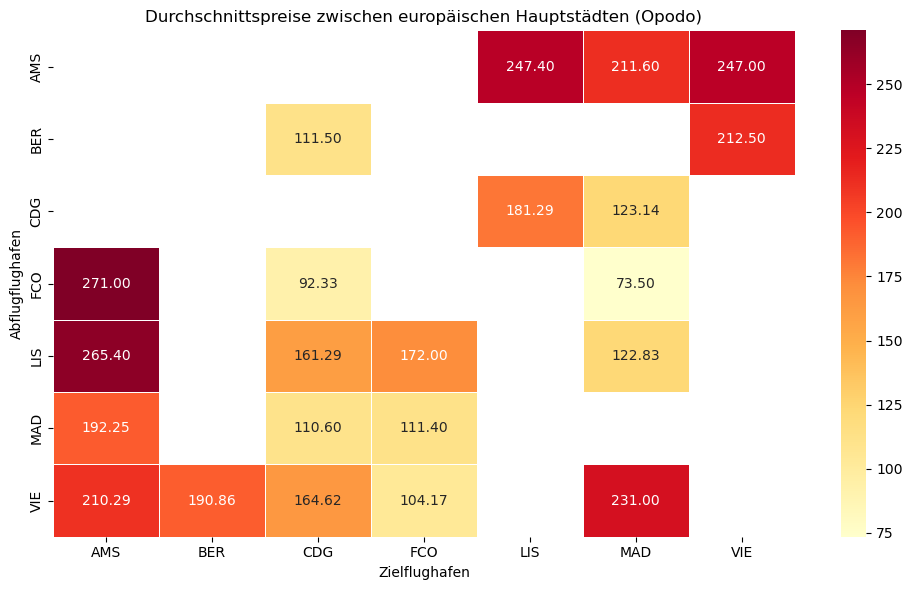

In [15]:
pivot = preis_matrix.pivot(index="Abflug", columns="Ziel", values="Durchschnittspreis")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Durchschnittspreise zwischen europäischen Hauptstädten (Opodo)")
plt.xlabel("Zielflughafen")
plt.ylabel("Abflugflughafen")
os.makedirs("Pictures", exist_ok=True)
plt.tight_layout()
plt.savefig("Pictures/durchschnittspreise_hauptstaedte_vergleich_opodo.png", dpi=300)
plt.show()

/tmp/ipykernel_4478/570150348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=opodo_pd_box, x="Domain", y="Preis", palette="Set2")


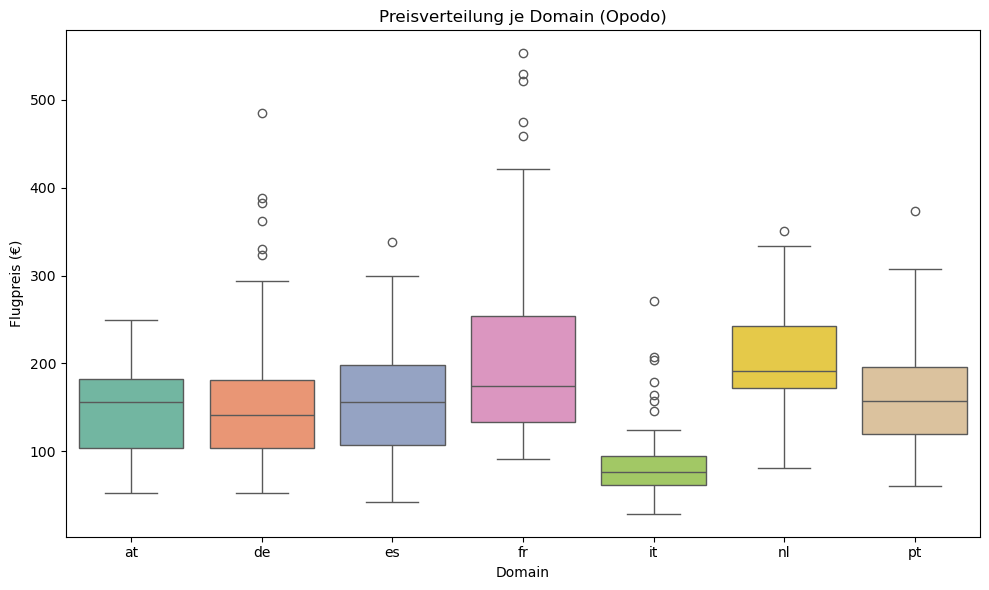

In [16]:
opodo_pd_box = opodo_df.select("Domain", "Preis").toPandas()
plt.figure(figsize=(10, 6))
sns.boxplot(data=opodo_pd_box, x="Domain", y="Preis", palette="Set2")
plt.title("Preisverteilung je Domain (Opodo)")
plt.xlabel("Domain")
plt.ylabel("Flugpreis (€)")
plt.tight_layout()
plt.savefig("Pictures/preisverteilung_je_domain_opodo.png", dpi=300)
plt.show()